In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset, random_split
import tifffile as tiff
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from PIL import Image

import joblib

# Cached version
class UnlabeledTIFFDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = [
            os.path.join(root_dir, fname)
            for fname in os.listdir(root_dir)
            if fname.lower().endswith(('tif', 'tiff'))
        ]

        self.data = []
        for img_path in self.image_paths:
            try:
                image = tiff.imread(img_path).astype(np.float32)
                image = image * 240
                image[image > 254] = 254
                if image.ndim == 3:
                    image = image[0]
                image = image / 255

                if self.transform:
                    image = self.transform(image)
                image = torch.tensor(image, dtype=torch.float32)  # shape: (1, H, W)
                self.data.append(image)
            except Exception as e:
                print(f"Warning: Skipping unreadable image {img_path} - {e}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image = self.data[idx]

        # Ensure it's a torch tensor
        if not isinstance(image, torch.Tensor):
            image = torch.tensor(image, dtype=torch.float32)

        # # Ensure shape is [1, H, W]
        # if image.ndim == 2:  # [H, W]
        #     image = image.unsqueeze(0)
        # elif image.ndim == 3 and image.shape[0] != 1:
        #     # If image is [C, H, W] but C != 1, take the first channel
        #     image = image[0].unsqueeze(0)

        return image, 0  # Dummy label


# Step 1: Define a standard Autoencoder (AE)
import torch
import numpy as np
from tqdm import tqdm
from torchvision import transforms
from skimage import io
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE


class AE(torch.nn.Module):
    def __init__(self, latent_dim=8):
        super(AE, self).__init__()
        self.encoder = torch.nn.Sequential(
            torch.nn.Conv2d(1, 32, 3, stride=2, padding=1),  # 32 -> 16
            torch.nn.LeakyReLU(0.01),
            torch.nn.Conv2d(32, 64, 3, stride=2, padding=1),  # 16 -> 8
            torch.nn.LeakyReLU(0.01),
            torch.nn.Conv2d(64, 128, 3, stride=2, padding=1),  # 8 -> 4
            torch.nn.LeakyReLU(0.01),
            torch.nn.Flatten()
        )
        self.encoder_fc = torch.nn.Sequential(
            torch.nn.Linear(128 * 4 * 4, 1024),
            torch.nn.LeakyReLU(0.01),
            torch.nn.Linear(1024, latent_dim)
        )

        self.decoder_fc = torch.nn.Sequential(
            torch.nn.Linear(latent_dim, 1024),
            torch.nn.LeakyReLU(0.01),
            torch.nn.Linear(1024, 128 * 4 * 4)
        )

        self.decoder = torch.nn.Sequential(
            torch.nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1),  # 4 -> 8
            torch.nn.LeakyReLU(0.01),
            torch.nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),  # 8 -> 16
            torch.nn.LeakyReLU(0.01),
            torch.nn.ConvTranspose2d(32, 1, 3, stride=2, padding=1, output_padding=1),   # 16 -> 32
            torch.nn.Sigmoid()
        )

    def encode(self, x):
        x = self.encoder(x)
        return self.encoder_fc(x)

    def decode(self, z):
        x = self.decoder_fc(z).view(-1, 128, 4, 4)
        return self.decoder(x)

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z), z

def plot_reconstruction_progress(model, dataloader, device, epoch):
    """Plot original vs reconstructed images during training"""
    model.eval()
    with torch.no_grad():
        for x, _ in dataloader:
            x = x.to(device)
            recon, _ = model(x)
            break  # only one batch

    x = x.cpu()
    recon = recon.cpu()

    print(f"Input stats — min: {x.min().item():.4f}, max: {x.max().item():.4f}, mean: {x.mean().item():.4f}, std: {x.std().item():.4f}")
    print(f"Reconstruction stats — min: {recon.min().item():.4f}, max: {recon.max().item():.4f}, mean: {recon.mean().item():.4f}, std: {recon.std().item():.4f}")

    n = min(8, x.size(0))
    fig, axes = plt.subplots(2, n, figsize=(n * 1, 2))
    for i in range(n):
        axes[0, i].imshow(x[i].squeeze(), cmap="gray", vmin=0, vmax=1)
        axes[0, i].axis("off")
        axes[1, i].imshow(recon[i].squeeze(), cmap="gray", vmin=0, vmax=1)
        axes[1, i].axis("off")
    plt.suptitle(f"Reconstruction at Epoch {epoch}")
    plt.tight_layout()
    plt.show()

import time

# Step 2: Train Autoencoder and Extract Latent Representations
def train_ae(model, train_loader, val_loader, epochs=2000, lr=1e-4):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        start_time = time.time()
        model.train()
        train_loss = 0.0
        for x, _ in train_loader:
            x = x.to(device)
            recon, _ = model(x)
            loss = loss_fn(recon, x)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x, _ in val_loader:
                x = x.to(device)
                recon, _ = model(x)
                loss = loss_fn(recon, x)
                val_loss += loss.item()
        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        end_time = time.time()
        epoch_time = end_time - start_time

        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Time: {epoch_time:.2f} sec")
            
        if (epoch + 1) % 100 == 0:
            plot_reconstruction_progress(model, val_loader, device, epoch + 1)
            

    # Plot training and validation loss
    plt.plot(range(epochs), train_losses, label='Train Loss')
    plt.plot(range(epochs), val_losses, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training vs Validation Loss')
    plt.show()

    return model


# Load Data
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

from torch.utils.data import ConcatDataset

dir1 = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/ctrl_ch1_major/patches_gridonly_pslocation00/tiff_patches32_65p_20250909_1521'
dir2 = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/y_ch1_major/y_ch1_patches_gridonly_pslocation00/tiff_patches32_65p_20250909_1532'

transform = transforms.Compose([transforms.ToTensor()])

ds1 = UnlabeledTIFFDataset(root_dir=dir1, transform=transform)
ds2 = UnlabeledTIFFDataset(root_dir=dir2, transform=transform)



dataset = ConcatDataset([ds1, ds2])


# Split dataset into training and validation sets
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

joblib.dump(train_loader, "train_loader_pax_ch1_ps32_ctrl_Y_grid_00_2000epoch.pkl")




/tmp/ipykernel_1055125/3839169534.py:39: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image, dtype=torch.float32)  # shape: (1, H, W)


['train_loader_pax_ch1_ps32_ctrl_Y_grid_00_2000epoch.pkl']

In [18]:
len(dataset)

6586

Epoch 20/2000, Train Loss: 0.0107, Val Loss: 0.0112, Time: 0.12 sec
Epoch 40/2000, Train Loss: 0.0101, Val Loss: 0.0109, Time: 0.11 sec
Epoch 60/2000, Train Loss: 0.0095, Val Loss: 0.0108, Time: 0.11 sec
Epoch 80/2000, Train Loss: 0.0089, Val Loss: 0.0110, Time: 0.11 sec
Epoch 100/2000, Train Loss: 0.0084, Val Loss: 0.0112, Time: 0.10 sec
Input stats — min: 0.0000, max: 0.9486, mean: 0.1296, std: 0.1511
Reconstruction stats — min: 0.0080, max: 0.9793, mean: 0.1279, std: 0.1180


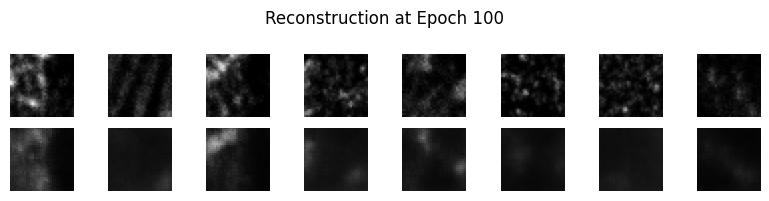

Epoch 120/2000, Train Loss: 0.0080, Val Loss: 0.0115, Time: 0.10 sec
Epoch 140/2000, Train Loss: 0.0076, Val Loss: 0.0118, Time: 0.11 sec
Epoch 160/2000, Train Loss: 0.0073, Val Loss: 0.0121, Time: 0.10 sec
Epoch 180/2000, Train Loss: 0.0071, Val Loss: 0.0125, Time: 0.12 sec
Epoch 200/2000, Train Loss: 0.0068, Val Loss: 0.0125, Time: 0.12 sec
Input stats — min: 0.0000, max: 0.9486, mean: 0.1296, std: 0.1511
Reconstruction stats — min: 0.0048, max: 0.9890, mean: 0.1282, std: 0.1248


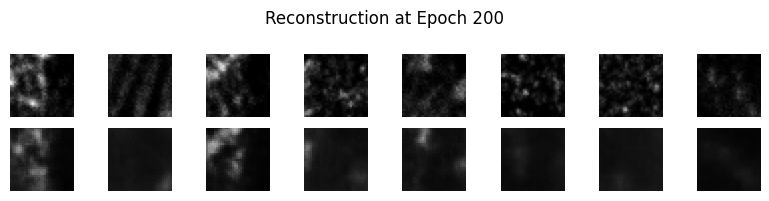

Epoch 220/2000, Train Loss: 0.0066, Val Loss: 0.0126, Time: 0.13 sec
Epoch 240/2000, Train Loss: 0.0064, Val Loss: 0.0129, Time: 0.13 sec
Epoch 260/2000, Train Loss: 0.0062, Val Loss: 0.0129, Time: 0.10 sec
Epoch 280/2000, Train Loss: 0.0061, Val Loss: 0.0133, Time: 0.12 sec
Epoch 300/2000, Train Loss: 0.0060, Val Loss: 0.0132, Time: 0.11 sec
Input stats — min: 0.0000, max: 0.9486, mean: 0.1296, std: 0.1511
Reconstruction stats — min: 0.0058, max: 0.9932, mean: 0.1290, std: 0.1289


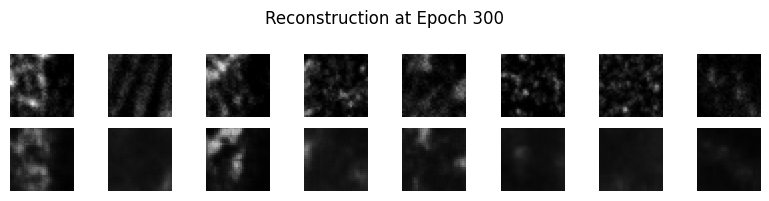

Epoch 320/2000, Train Loss: 0.0058, Val Loss: 0.0135, Time: 0.11 sec
Epoch 340/2000, Train Loss: 0.0057, Val Loss: 0.0135, Time: 0.10 sec
Epoch 360/2000, Train Loss: 0.0056, Val Loss: 0.0137, Time: 0.10 sec
Epoch 380/2000, Train Loss: 0.0055, Val Loss: 0.0138, Time: 0.10 sec
Epoch 400/2000, Train Loss: 0.0054, Val Loss: 0.0137, Time: 0.10 sec
Input stats — min: 0.0000, max: 0.9486, mean: 0.1296, std: 0.1511
Reconstruction stats — min: 0.0043, max: 0.9968, mean: 0.1248, std: 0.1291


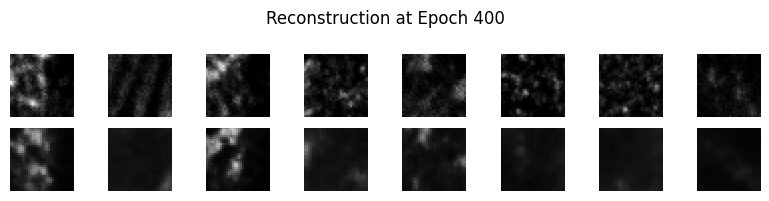

Epoch 420/2000, Train Loss: 0.0053, Val Loss: 0.0138, Time: 0.11 sec
Epoch 440/2000, Train Loss: 0.0052, Val Loss: 0.0140, Time: 0.11 sec
Epoch 460/2000, Train Loss: 0.0050, Val Loss: 0.0140, Time: 0.12 sec
Epoch 480/2000, Train Loss: 0.0050, Val Loss: 0.0141, Time: 0.10 sec
Epoch 500/2000, Train Loss: 0.0049, Val Loss: 0.0141, Time: 0.11 sec
Input stats — min: 0.0000, max: 0.9486, mean: 0.1296, std: 0.1511
Reconstruction stats — min: 0.0036, max: 0.9943, mean: 0.1295, std: 0.1304


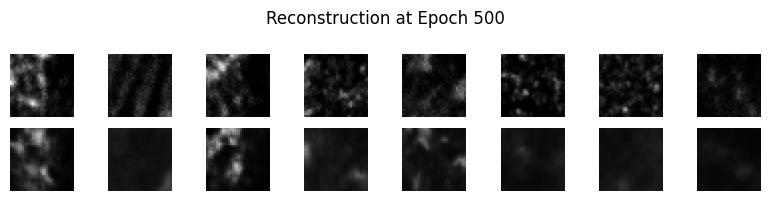

Epoch 520/2000, Train Loss: 0.0049, Val Loss: 0.0143, Time: 0.11 sec
Epoch 540/2000, Train Loss: 0.0048, Val Loss: 0.0144, Time: 0.10 sec
Epoch 560/2000, Train Loss: 0.0047, Val Loss: 0.0143, Time: 0.10 sec
Epoch 580/2000, Train Loss: 0.0046, Val Loss: 0.0145, Time: 0.11 sec
Epoch 600/2000, Train Loss: 0.0046, Val Loss: 0.0144, Time: 0.10 sec
Input stats — min: 0.0000, max: 0.9486, mean: 0.1296, std: 0.1511
Reconstruction stats — min: 0.0029, max: 0.9932, mean: 0.1299, std: 0.1310


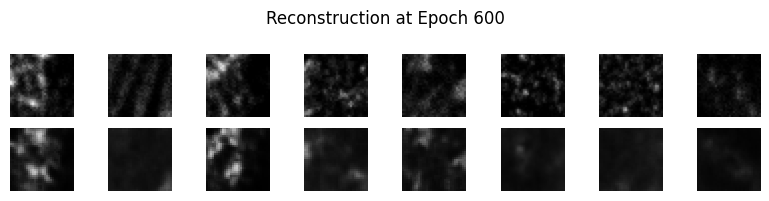

Epoch 620/2000, Train Loss: 0.0045, Val Loss: 0.0146, Time: 0.11 sec
Epoch 640/2000, Train Loss: 0.0045, Val Loss: 0.0145, Time: 0.10 sec
Epoch 660/2000, Train Loss: 0.0044, Val Loss: 0.0147, Time: 0.12 sec
Epoch 680/2000, Train Loss: 0.0044, Val Loss: 0.0147, Time: 0.10 sec
Epoch 700/2000, Train Loss: 0.0043, Val Loss: 0.0149, Time: 0.11 sec
Input stats — min: 0.0000, max: 0.9486, mean: 0.1296, std: 0.1511
Reconstruction stats — min: 0.0021, max: 0.9953, mean: 0.1325, std: 0.1340


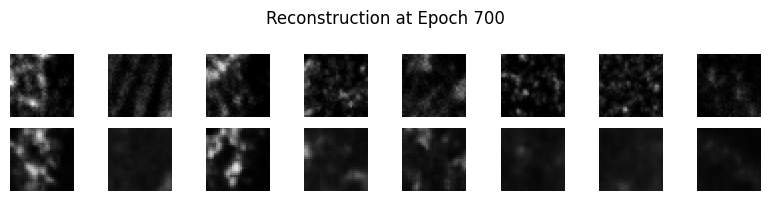

Epoch 720/2000, Train Loss: 0.0043, Val Loss: 0.0147, Time: 0.11 sec
Epoch 740/2000, Train Loss: 0.0042, Val Loss: 0.0148, Time: 0.10 sec
Epoch 760/2000, Train Loss: 0.0042, Val Loss: 0.0150, Time: 0.11 sec
Epoch 780/2000, Train Loss: 0.0041, Val Loss: 0.0149, Time: 0.14 sec
Epoch 800/2000, Train Loss: 0.0041, Val Loss: 0.0150, Time: 0.11 sec
Input stats — min: 0.0000, max: 0.9486, mean: 0.1296, std: 0.1511
Reconstruction stats — min: 0.0012, max: 0.9933, mean: 0.1283, std: 0.1356


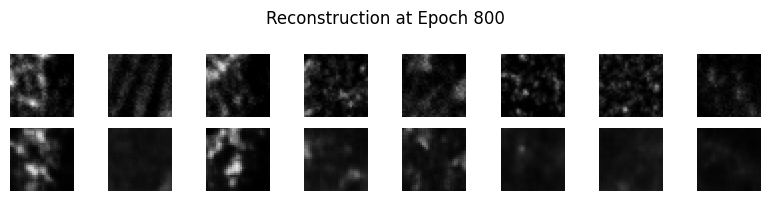

Epoch 820/2000, Train Loss: 0.0040, Val Loss: 0.0152, Time: 0.10 sec
Epoch 840/2000, Train Loss: 0.0040, Val Loss: 0.0150, Time: 0.13 sec
Epoch 860/2000, Train Loss: 0.0040, Val Loss: 0.0155, Time: 0.13 sec
Epoch 880/2000, Train Loss: 0.0040, Val Loss: 0.0151, Time: 0.12 sec
Epoch 900/2000, Train Loss: 0.0039, Val Loss: 0.0152, Time: 0.10 sec
Input stats — min: 0.0000, max: 0.9486, mean: 0.1296, std: 0.1511
Reconstruction stats — min: 0.0018, max: 0.9959, mean: 0.1315, std: 0.1364


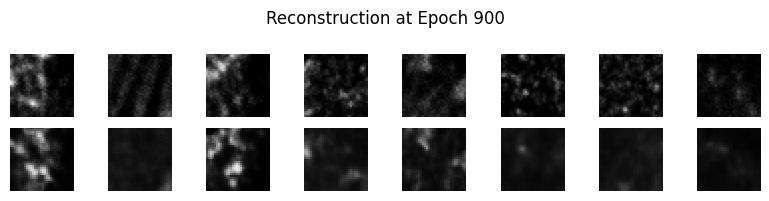

Epoch 920/2000, Train Loss: 0.0038, Val Loss: 0.0152, Time: 0.11 sec
Epoch 940/2000, Train Loss: 0.0038, Val Loss: 0.0152, Time: 0.11 sec
Epoch 960/2000, Train Loss: 0.0038, Val Loss: 0.0150, Time: 0.10 sec
Epoch 980/2000, Train Loss: 0.0037, Val Loss: 0.0154, Time: 0.10 sec
Epoch 1000/2000, Train Loss: 0.0037, Val Loss: 0.0154, Time: 0.10 sec
Input stats — min: 0.0000, max: 0.9486, mean: 0.1296, std: 0.1511
Reconstruction stats — min: 0.0009, max: 0.9944, mean: 0.1322, std: 0.1366


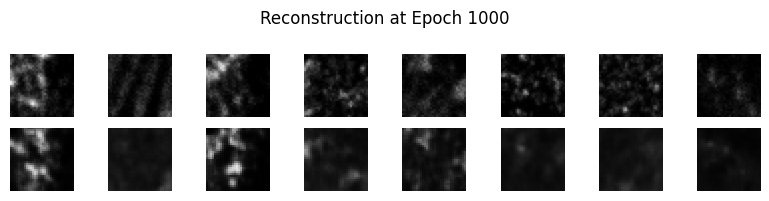

Epoch 1020/2000, Train Loss: 0.0037, Val Loss: 0.0155, Time: 0.11 sec
Epoch 1040/2000, Train Loss: 0.0036, Val Loss: 0.0154, Time: 0.12 sec
Epoch 1060/2000, Train Loss: 0.0036, Val Loss: 0.0153, Time: 0.12 sec
Epoch 1080/2000, Train Loss: 0.0036, Val Loss: 0.0154, Time: 0.11 sec
Epoch 1100/2000, Train Loss: 0.0035, Val Loss: 0.0156, Time: 0.10 sec
Input stats — min: 0.0000, max: 0.9486, mean: 0.1296, std: 0.1511
Reconstruction stats — min: 0.0009, max: 0.9948, mean: 0.1284, std: 0.1373


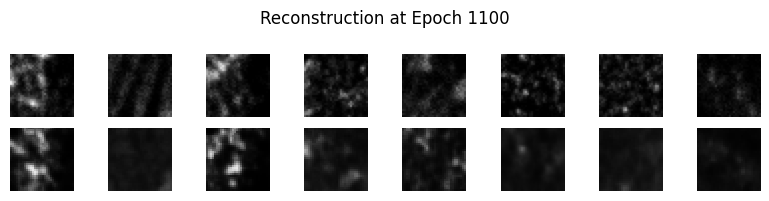

Epoch 1120/2000, Train Loss: 0.0035, Val Loss: 0.0155, Time: 0.11 sec
Epoch 1140/2000, Train Loss: 0.0035, Val Loss: 0.0155, Time: 0.11 sec
Epoch 1160/2000, Train Loss: 0.0035, Val Loss: 0.0157, Time: 0.11 sec
Epoch 1180/2000, Train Loss: 0.0035, Val Loss: 0.0155, Time: 0.10 sec
Epoch 1200/2000, Train Loss: 0.0034, Val Loss: 0.0155, Time: 0.11 sec
Input stats — min: 0.0000, max: 0.9486, mean: 0.1296, std: 0.1511
Reconstruction stats — min: 0.0007, max: 0.9926, mean: 0.1271, std: 0.1370


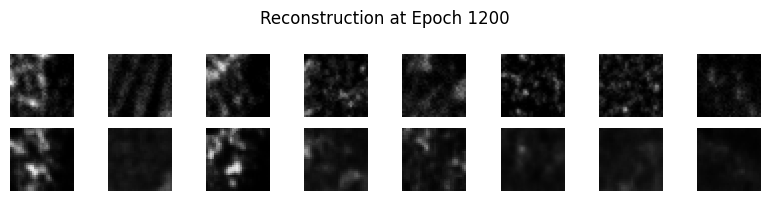

Epoch 1220/2000, Train Loss: 0.0034, Val Loss: 0.0155, Time: 0.10 sec
Epoch 1240/2000, Train Loss: 0.0034, Val Loss: 0.0156, Time: 0.11 sec
Epoch 1260/2000, Train Loss: 0.0034, Val Loss: 0.0157, Time: 0.12 sec
Epoch 1280/2000, Train Loss: 0.0033, Val Loss: 0.0156, Time: 0.11 sec
Epoch 1300/2000, Train Loss: 0.0033, Val Loss: 0.0158, Time: 0.11 sec
Input stats — min: 0.0000, max: 0.9486, mean: 0.1296, std: 0.1511
Reconstruction stats — min: 0.0004, max: 0.9928, mean: 0.1312, std: 0.1392


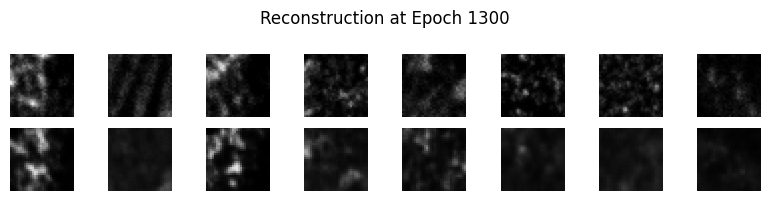

Epoch 1320/2000, Train Loss: 0.0033, Val Loss: 0.0157, Time: 0.13 sec
Epoch 1340/2000, Train Loss: 0.0033, Val Loss: 0.0157, Time: 0.11 sec
Epoch 1360/2000, Train Loss: 0.0032, Val Loss: 0.0160, Time: 0.11 sec
Epoch 1380/2000, Train Loss: 0.0032, Val Loss: 0.0160, Time: 0.10 sec
Epoch 1400/2000, Train Loss: 0.0032, Val Loss: 0.0159, Time: 0.11 sec
Input stats — min: 0.0000, max: 0.9486, mean: 0.1296, std: 0.1511
Reconstruction stats — min: 0.0004, max: 0.9895, mean: 0.1304, std: 0.1404


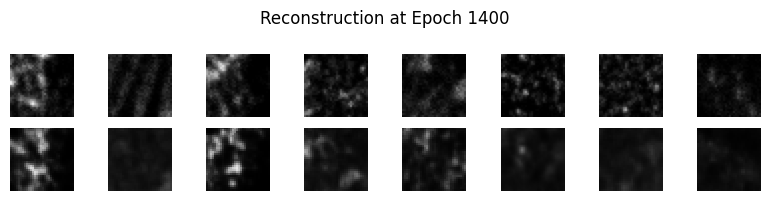

Epoch 1420/2000, Train Loss: 0.0032, Val Loss: 0.0159, Time: 0.10 sec
Epoch 1440/2000, Train Loss: 0.0031, Val Loss: 0.0160, Time: 0.10 sec
Epoch 1460/2000, Train Loss: 0.0032, Val Loss: 0.0159, Time: 0.10 sec
Epoch 1480/2000, Train Loss: 0.0031, Val Loss: 0.0160, Time: 0.11 sec
Epoch 1500/2000, Train Loss: 0.0031, Val Loss: 0.0161, Time: 0.12 sec
Input stats — min: 0.0000, max: 0.9486, mean: 0.1296, std: 0.1511
Reconstruction stats — min: 0.0003, max: 0.9881, mean: 0.1313, std: 0.1413


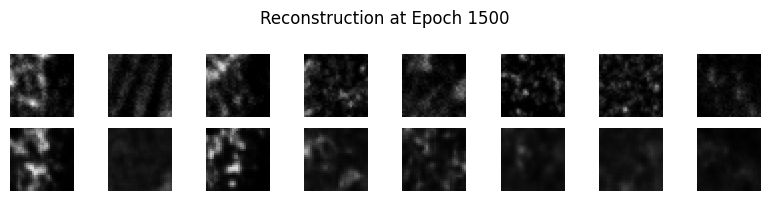

Epoch 1520/2000, Train Loss: 0.0031, Val Loss: 0.0159, Time: 0.13 sec
Epoch 1540/2000, Train Loss: 0.0030, Val Loss: 0.0161, Time: 0.13 sec
Epoch 1560/2000, Train Loss: 0.0030, Val Loss: 0.0161, Time: 0.13 sec
Epoch 1580/2000, Train Loss: 0.0030, Val Loss: 0.0163, Time: 0.13 sec
Epoch 1600/2000, Train Loss: 0.0030, Val Loss: 0.0161, Time: 0.11 sec
Input stats — min: 0.0000, max: 0.9486, mean: 0.1296, std: 0.1511
Reconstruction stats — min: 0.0003, max: 0.9853, mean: 0.1320, std: 0.1403


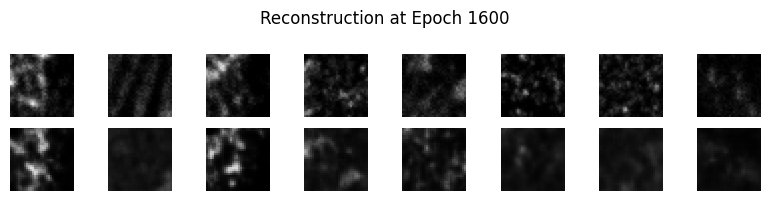

Epoch 1620/2000, Train Loss: 0.0030, Val Loss: 0.0160, Time: 0.10 sec
Epoch 1640/2000, Train Loss: 0.0030, Val Loss: 0.0164, Time: 0.10 sec
Epoch 1660/2000, Train Loss: 0.0030, Val Loss: 0.0163, Time: 0.10 sec
Epoch 1680/2000, Train Loss: 0.0030, Val Loss: 0.0159, Time: 0.10 sec
Epoch 1700/2000, Train Loss: 0.0029, Val Loss: 0.0161, Time: 0.10 sec
Input stats — min: 0.0000, max: 0.9486, mean: 0.1296, std: 0.1511
Reconstruction stats — min: 0.0003, max: 0.9844, mean: 0.1297, std: 0.1404


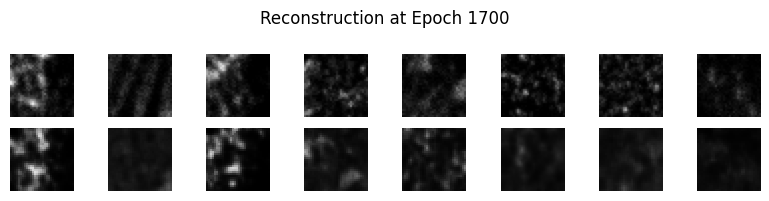

Epoch 1720/2000, Train Loss: 0.0029, Val Loss: 0.0160, Time: 0.12 sec
Epoch 1740/2000, Train Loss: 0.0030, Val Loss: 0.0162, Time: 0.13 sec
Epoch 1760/2000, Train Loss: 0.0029, Val Loss: 0.0162, Time: 0.12 sec
Epoch 1780/2000, Train Loss: 0.0029, Val Loss: 0.0163, Time: 0.11 sec
Epoch 1800/2000, Train Loss: 0.0029, Val Loss: 0.0161, Time: 0.11 sec
Input stats — min: 0.0000, max: 0.9486, mean: 0.1296, std: 0.1511
Reconstruction stats — min: 0.0003, max: 0.9853, mean: 0.1280, std: 0.1406


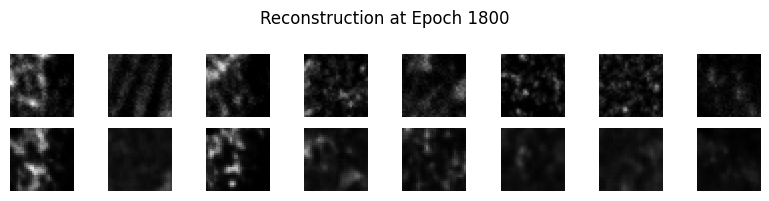

Epoch 1820/2000, Train Loss: 0.0028, Val Loss: 0.0163, Time: 0.11 sec
Epoch 1840/2000, Train Loss: 0.0028, Val Loss: 0.0164, Time: 0.13 sec
Epoch 1860/2000, Train Loss: 0.0028, Val Loss: 0.0162, Time: 0.11 sec
Epoch 1880/2000, Train Loss: 0.0028, Val Loss: 0.0163, Time: 0.11 sec
Epoch 1900/2000, Train Loss: 0.0028, Val Loss: 0.0161, Time: 0.12 sec
Input stats — min: 0.0000, max: 0.9486, mean: 0.1296, std: 0.1511
Reconstruction stats — min: 0.0002, max: 0.9846, mean: 0.1260, std: 0.1399


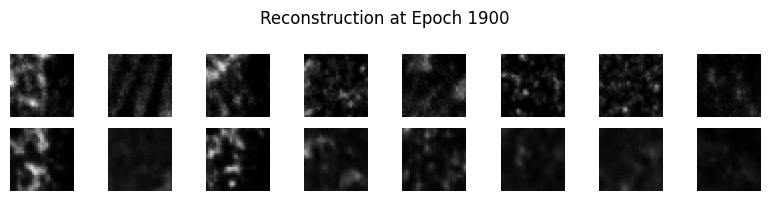

Epoch 1920/2000, Train Loss: 0.0028, Val Loss: 0.0164, Time: 0.11 sec
Epoch 1940/2000, Train Loss: 0.0028, Val Loss: 0.0164, Time: 0.14 sec
Epoch 1960/2000, Train Loss: 0.0028, Val Loss: 0.0165, Time: 0.11 sec
Epoch 1980/2000, Train Loss: 0.0028, Val Loss: 0.0166, Time: 0.12 sec
Epoch 2000/2000, Train Loss: 0.0027, Val Loss: 0.0163, Time: 0.11 sec
Input stats — min: 0.0000, max: 0.9486, mean: 0.1296, std: 0.1511
Reconstruction stats — min: 0.0002, max: 0.9817, mean: 0.1295, std: 0.1407


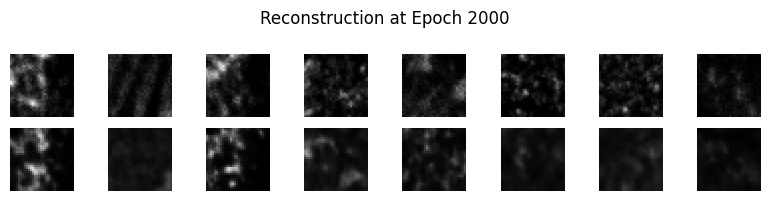

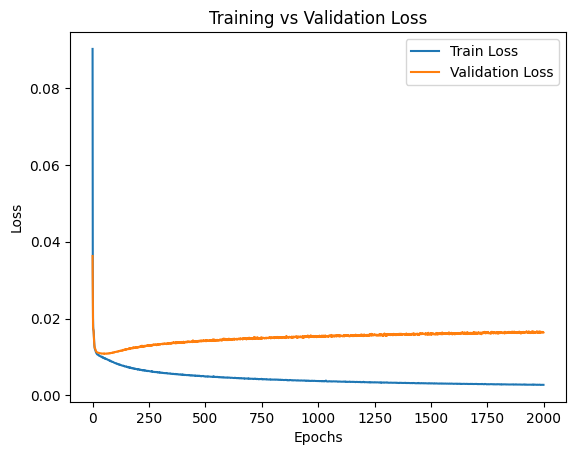

In [19]:
# Train AE
ae = AE().to(device)
ae = train_ae(ae, train_loader, val_loader)

torch.save(ae, 'pax_ch1_ps32_ctrl_Y_grid_00_bestmodel_2000epoch.pt')

In [20]:
len(ds1)

4205

In [21]:
len(ds2)


2381

In [22]:
import torch
import numpy as np
from tqdm import tqdm
from torchvision import transforms
from skimage import io
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from umap import UMAP


# Step 3: Cluster in Latent Space

def cluster_latents(model, dataloader, num_clusters=6):
    model.eval()
    latents = []
    images = []
    with torch.no_grad():
        for x, _ in dataloader:
            x = x.to(device)
            _, z = model(x)
            latents.append(z.cpu().numpy())
            images.append(x.cpu())
    latents = np.concatenate(latents, axis=0)
    images = torch.cat(images, dim=0)

       # Save model
    joblib.dump(latents, "latents_8d_pax_ch1_ps32_ctrl_Y_grid_00_2000epoch.pkl")
    joblib.dump(images, "train_images__pax_ch1_ps32_ctrl_Y_grid_00_2000epoch.pkl")


    kmeans = KMeans(n_clusters=num_clusters, random_state=0).fit(latents)
    labels = kmeans.labels_

    # Save the model
    joblib.dump(kmeans, "kmeans_model_pax_ch1_ps32_ctrl_Y_grid_00_2000epoch.pkl")
    return latents, labels, images

# Step 4: Visualize Clusters with t-SNE and Reconstructed Images

def visualize_clusters(latents, labels, images, model):


    umap = UMAP(n_components=2, random_state=42)
    latents_2d = umap.fit_transform(latents)

    # Save model
    joblib.dump(latents_2d, "latents_2d_pax_ch1_ps32_ctrl_Y_grid_00_2000epoch.pkl")


    # Save model
    joblib.dump(umap, "umap_model_pax_ch1_ps32_ctrl_Y_grid_00_2000epoch.pkl")

    plt.figure(figsize=(5, 3.5))
    plt.scatter(latents_2d[:, 0], latents_2d[:, 1], c=labels, cmap='tab10', alpha=0.7, s=1)
    plt.xlabel("UMAP1")
    plt.ylabel("UMAP2")
    plt.title("2D Visualization of Latent Space using UMAP")
    plt.show()

    selected_images = []
    selected_labels = set()
    for i, label in enumerate(labels):
        if label not in selected_labels:
            selected_labels.add(label)
            selected_images.append(images[i])
        if len(selected_labels) == 4:
            break

    selected_images = torch.stack(selected_images).to(device)
    reconstructed, _ = model(selected_images)

    fig, axes = plt.subplots(2, len(selected_images), figsize=(15, 5))
    for i in range(len(selected_images)):
        axes[0, i].imshow(selected_images[i].squeeze().cpu(), cmap='gray', vmax=1.0, vmin=0)
        axes[1, i].imshow(reconstructed[i].squeeze().cpu().detach(), cmap='gray', vmax=1.0, vmin=0)
        axes[0, i].axis('off')
        axes[1, i].axis('off')
    plt.show()
    return latents_2d


In [23]:
import torch
import numpy as np
from tqdm import tqdm
from torchvision import transforms
from skimage import io
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE


# Step 5: Show multiple decoded images per cluster

def cluster_and_display_images(latents, labels, images, model, num_samples_per_cluster=10):
    unique_labels = np.unique(labels)
    fig, axes = plt.subplots(len(unique_labels)*2, num_samples_per_cluster, figsize=(num_samples_per_cluster*1.5, len(unique_labels)*2))

    for cluster_idx, cluster_label in enumerate(unique_labels):
        cluster_indices = np.where(labels == cluster_label)[0][:num_samples_per_cluster]
        cluster_images = images[cluster_indices].to(device)
        recon_images, _ = model(cluster_images)

        for i in range(num_samples_per_cluster):
            axes[2 * cluster_idx, i].imshow(cluster_images[i].squeeze().cpu(), cmap='gray', vmin=0, vmax=1.0)
            axes[2 * cluster_idx + 1, i].imshow(recon_images[i].squeeze().cpu().detach(), cmap='gray', vmin=0, vmax=1.0)
            axes[2 * cluster_idx, i].axis('off')
            axes[2 * cluster_idx + 1, i].axis('off')

    plt.tight_layout()
    plt.show()


In [24]:
def cluster_2Dplot(latents, ind1,ind2,labels):
    plt.figure(figsize=(8, 6))
    plt.scatter(latents[:, ind1], latents[:, ind2], c=labels, cmap='tab10', alpha=0.7, s=1)
    plt.xlabel("F1")
    plt.ylabel("F2")
    plt.title("2D Visualization of Latent Space F0-F1")
    plt.show()
    

In [25]:
def cluster_3Dplot(latents, ind1,ind2,ind3, labels):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(latents[:, ind1], latents[:, ind2],latents[:, ind3], c=labels, cmap='tab10',s=1)
    plt.xlabel('F'+str(ind1))
    plt.ylabel('F'+str(ind2))
    plt.ylabel('F'+str(ind3))
    plt.title('3D Visualization of Latent Space F' +str(ind1)+'-'+str(ind2)+'-'+str(ind3))
    plt.show()
    

In [26]:
latents, labels, images = cluster_latents(ae, train_loader, num_clusters=6)


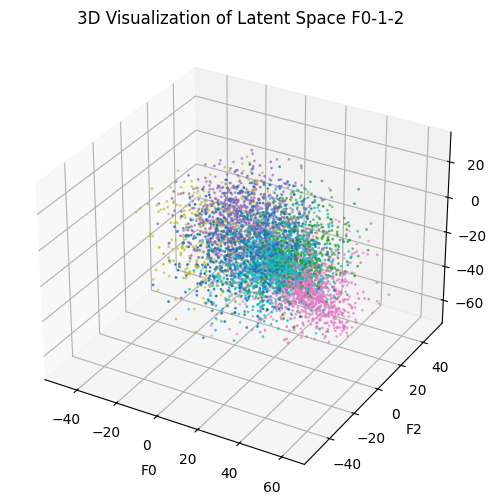

In [27]:
cluster_3Dplot(latents, 0,1,2,labels)

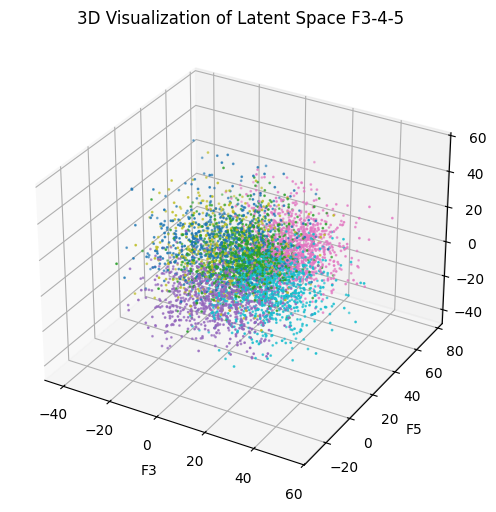

In [28]:
cluster_3Dplot(latents, 3,4,5,labels)

In [29]:
images.shape

torch.Size([5268, 1, 32, 32])

In [30]:
pax_ctrl_loader = DataLoader(ds1, batch_size=128, shuffle=False)
pax_y_loader = DataLoader(ds2, batch_size=128, shuffle=False)

/home/ldin/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


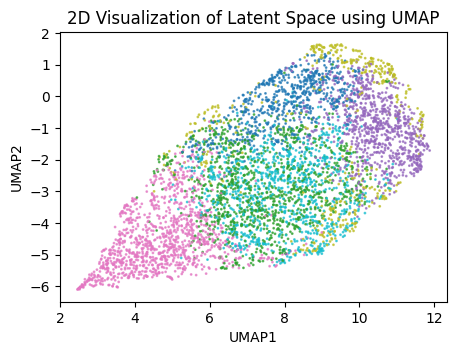

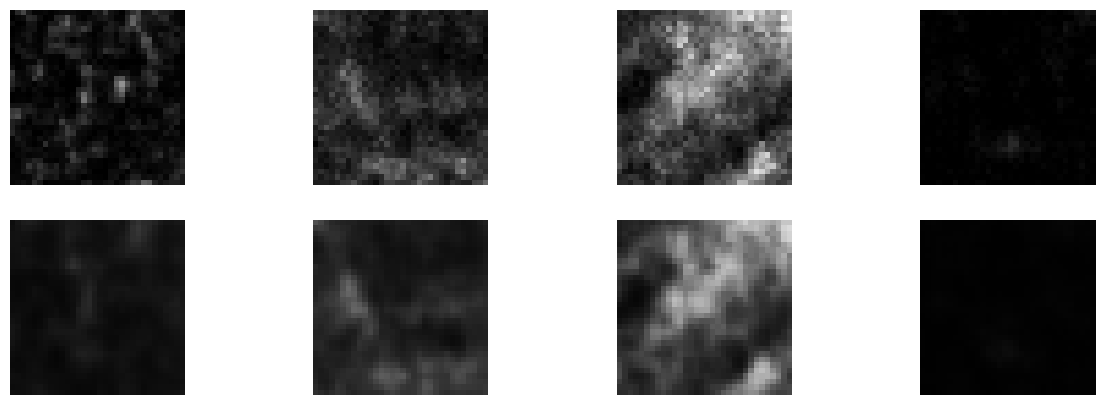

In [31]:
latents_2d = visualize_clusters(latents, labels, images, ae)


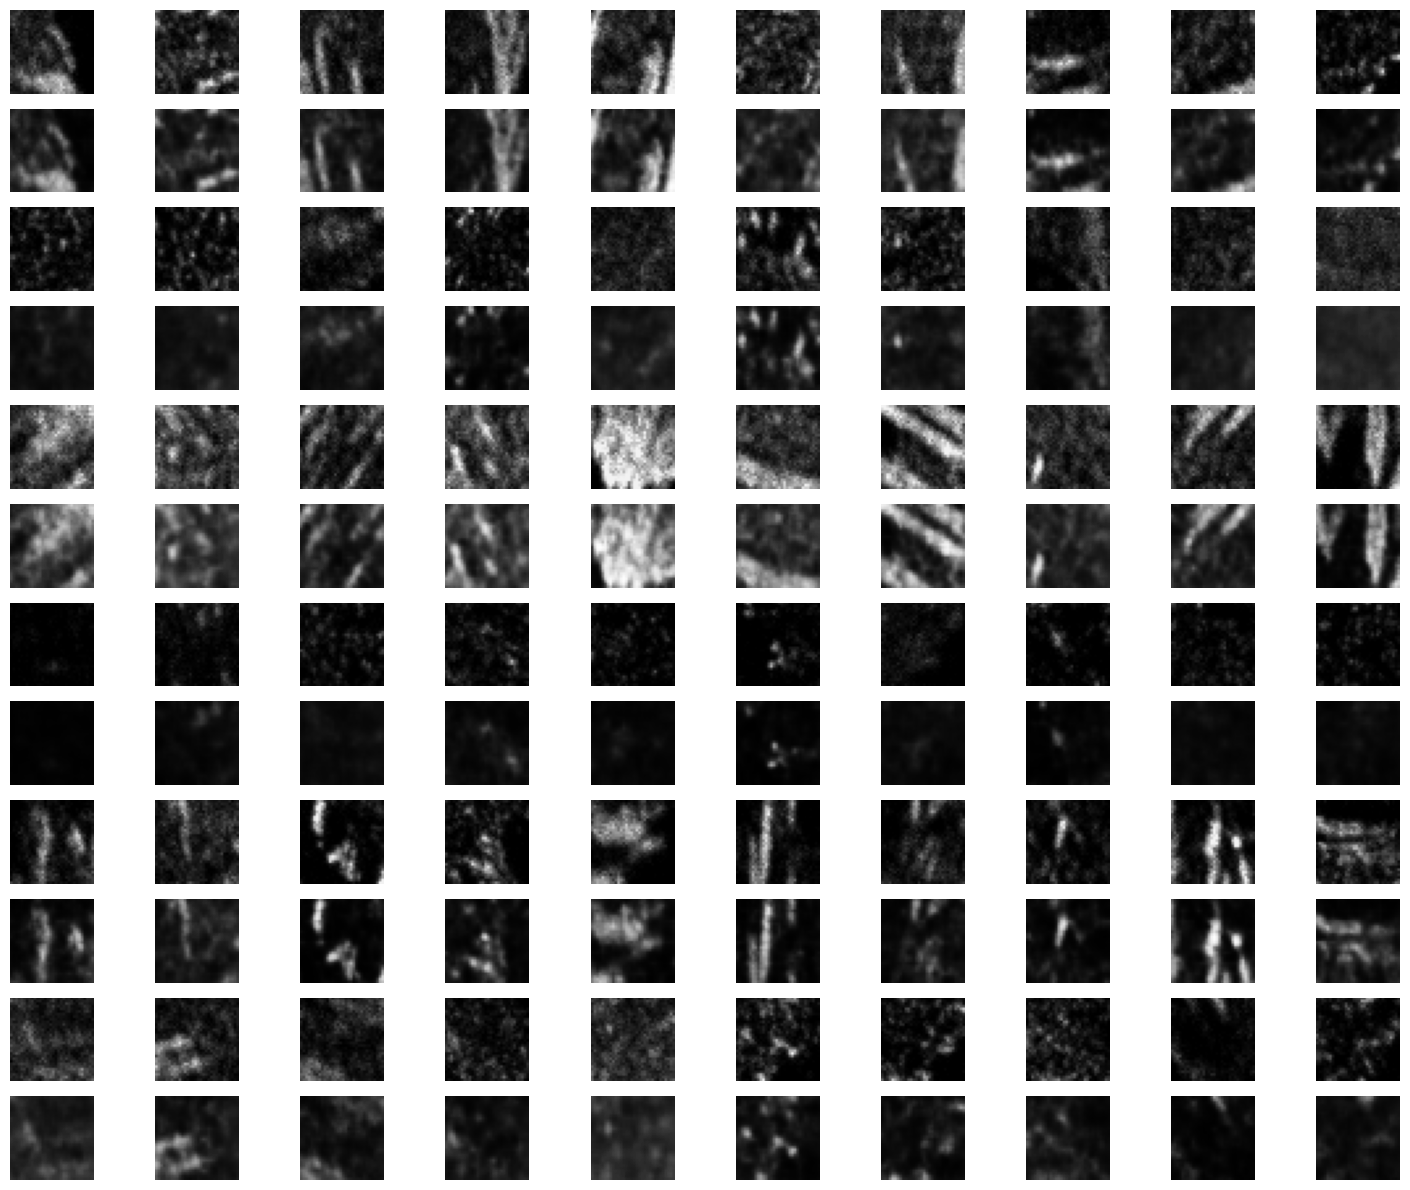

In [32]:
cluster_and_display_images(latents, labels, images, ae, num_samples_per_cluster=10)
